In [24]:
%load_ext autoreload
%autoreload 2
import numpy as np
import unyt as u
import os
import glob
import re
import matplotlib.pyplot as plt

import richio
import dev

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


t_fb= 0.0463092601376207 dimensionless


/home/hey4/.conda/envs/richanalysis/lib/python3.13/site-packages/unyt/array.py:1832: RuntimeWarning: invalid value encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


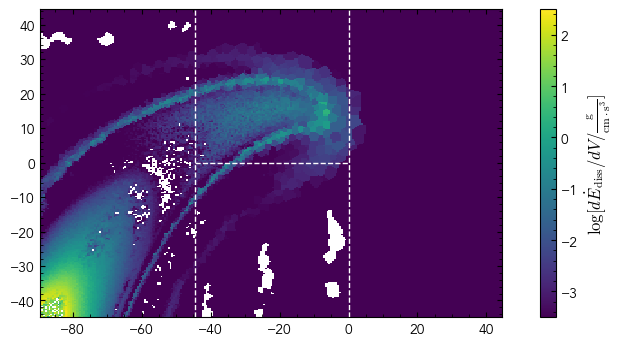

t_fb= 0.12180217395060396 dimensionless


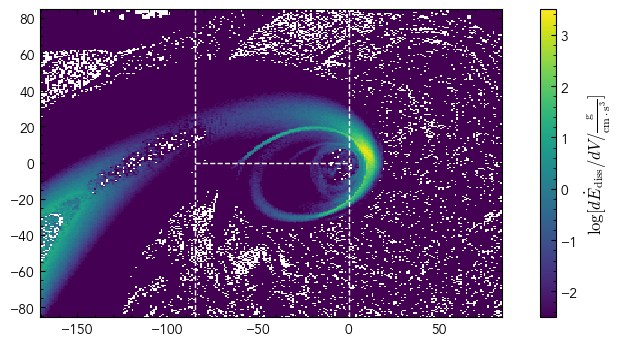

t_fb= 0.24713365436752613 dimensionless


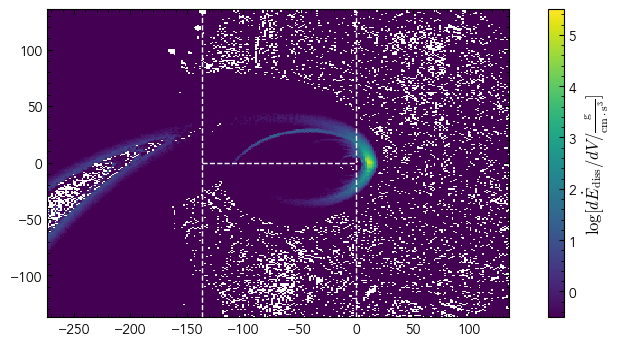

t_fb= 0.4347243129768847 dimensionless


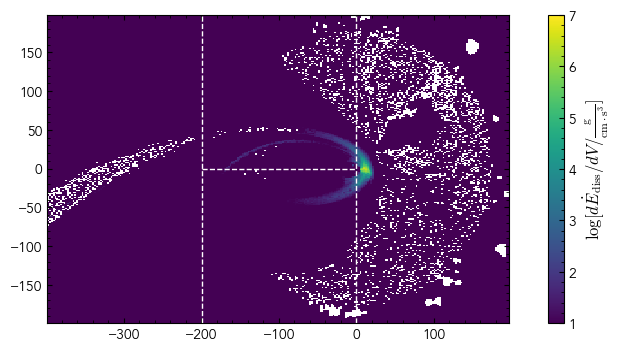

t_fb= 0.6738150129708113 dimensionless


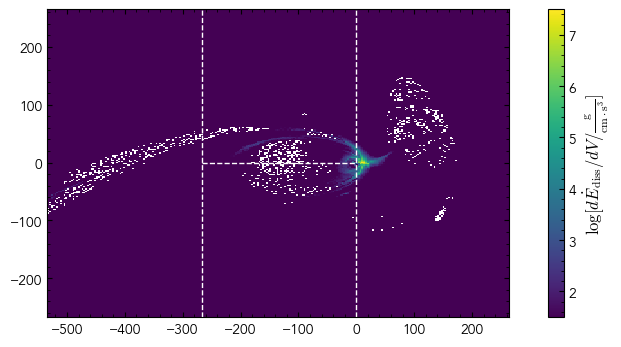

t_fb= 0.8977677118836747 dimensionless


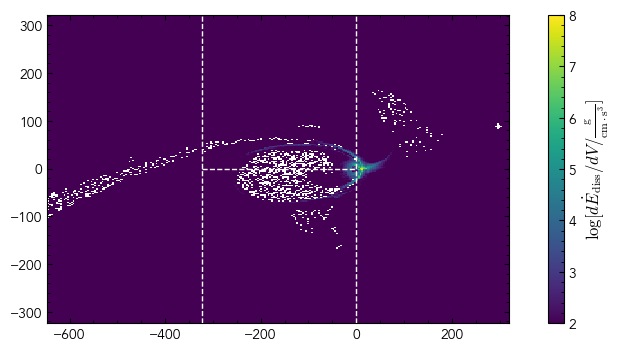

t_fb= 1.0559326395654778 dimensionless


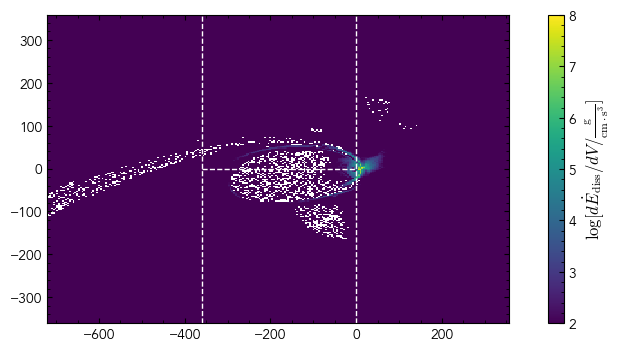

t_fb= 1.2141018677724082 dimensionless


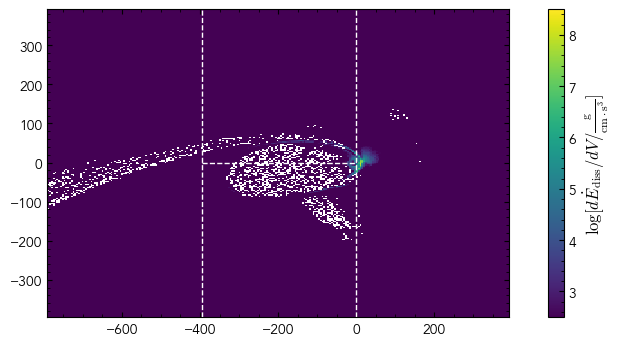

t_fb= 1.3722639123500922 dimensionless


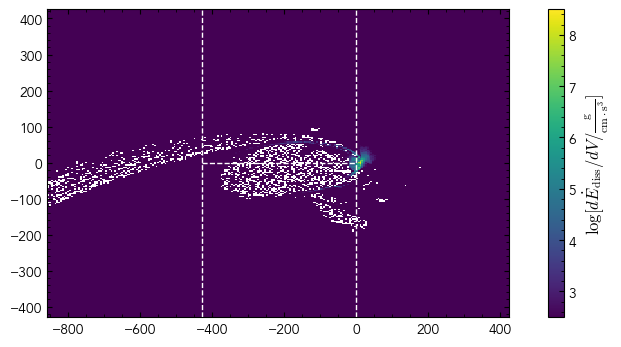

t_fb= 1.5304256304945272 dimensionless


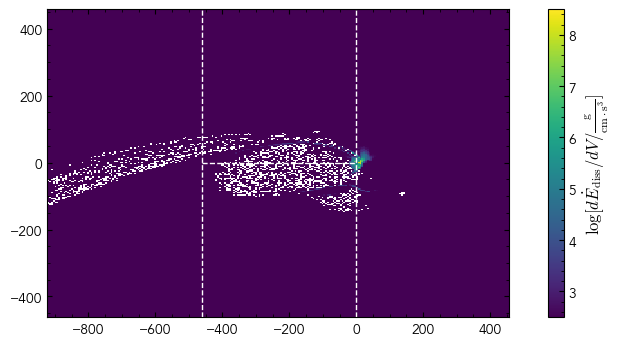

t_fb= 1.6885871058881319 dimensionless


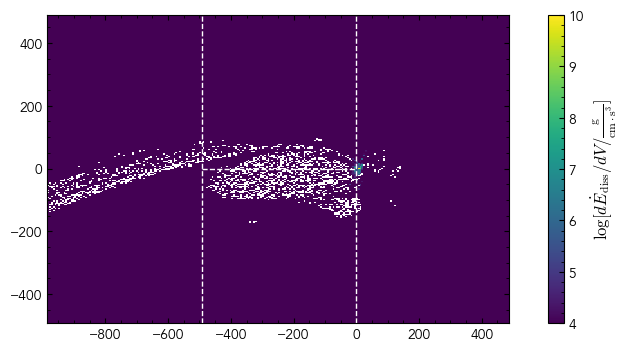

t_fb= 1.844648577682405 dimensionless


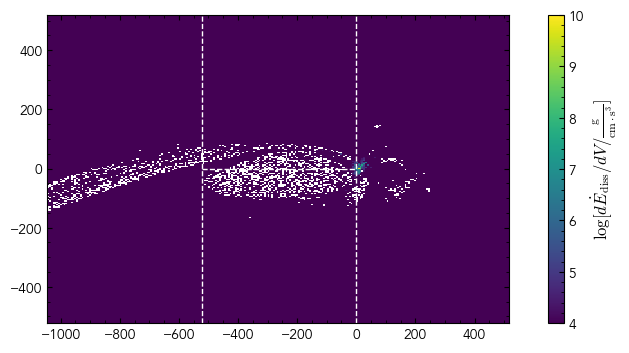

t_fb= 2.002807288479276 dimensionless


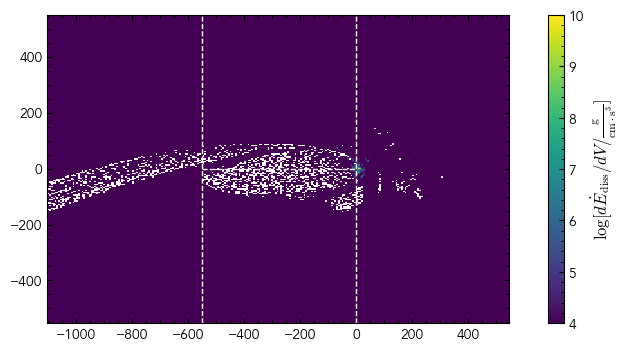

t_fb= 2.160985807933775 dimensionless


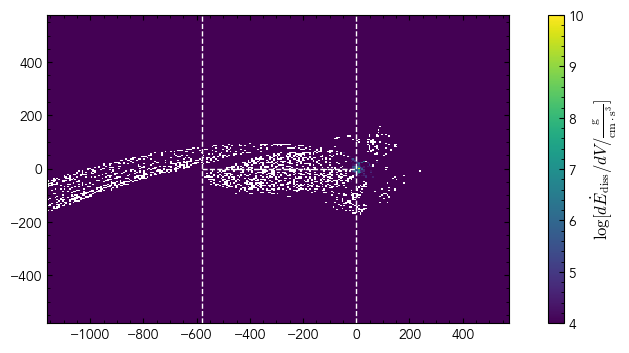

In [25]:
DATADIR = "/data1/projects/pi-rossiem/TDE_data/R0.47M0.5BH10000beta1S60n1.5ComptonHiResNewAMR/"
NCADENCE = 10

Rstar = 0.47 * richio.units.lscale
Mstar = 0.5 * richio.units.mscale
Mbh = 1e4 * richio.units.mscale
r_p = Rstar * (Mbh / Mstar) ** (1 / 3) * 1
r_amin = Rstar * (Mbh / Mstar) ** (2 / 3)
tmin = (
    np.pi / np.sqrt(2) * (Rstar**3 / u.G / Mstar) ** (1 / 2) * (Mbh / Mstar) ** (1 / 2)
)
Delta = u.G * Mbh / (4 * r_p) * Mstar

snap_files = sorted(
    glob.glob(os.path.join(DATADIR, "snap_*")),
    key=lambda f: int(re.search(r"snap_(\d+)", f).group(1)),
)

for snap_file in snap_files[21::NCADENCE]:

    snap = richio.load(snap_file)

    t = snap.tfb
    if t < 0:
        continue
    t_in_tmin = t / tmin
    r_a = r_amin * (t_in_tmin) ** (2 / 3)
    print("t_fb=", t_in_tmin)

    fig, ax = plt.subplots(figsize=(10, 4))
    snap.plots.slice(
        data="dissipation", res=256, X='CMx', Y='CMy', Z='CMz',
        box_size=[-2*r_a, - r_a, r_a, r_a],
        label_latex=r'd\dot{E}_\mathrm{diss}/dV',
        ax=ax, cmap="viridis"
    )

    ax.axvline(0, color="white", linestyle="--", linewidth=1)
    ax.axvline(-r_a, color="white", linestyle="--", linewidth=1)
    ax.plot([-r_a, 0], [0, 0], color="white", linestyle="--", linewidth=1)
    plt.show()

t_fb= 0.0463092601376207 dimensionless


/home/hey4/.conda/envs/richanalysis/lib/python3.13/site-packages/unyt/array.py:1832: RuntimeWarning: invalid value encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


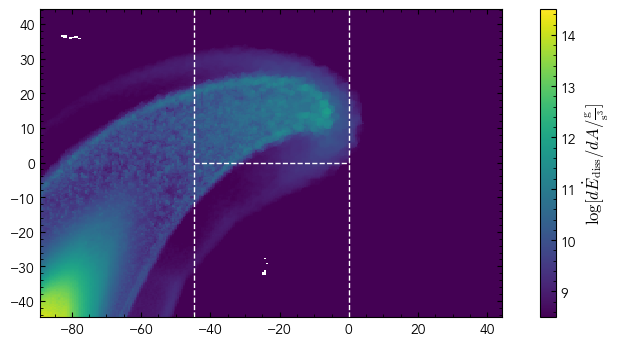

t_fb= 0.12180217395060396 dimensionless


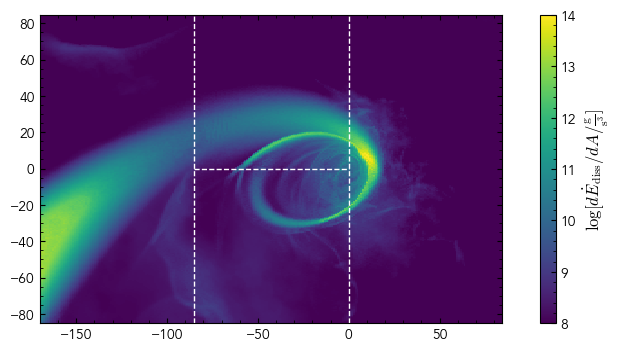

t_fb= 0.24713365436752613 dimensionless


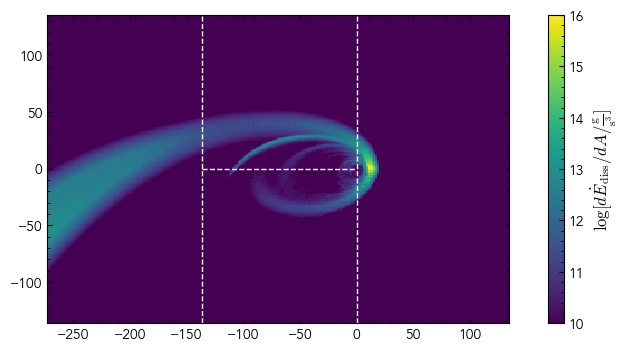

t_fb= 0.4347243129768847 dimensionless


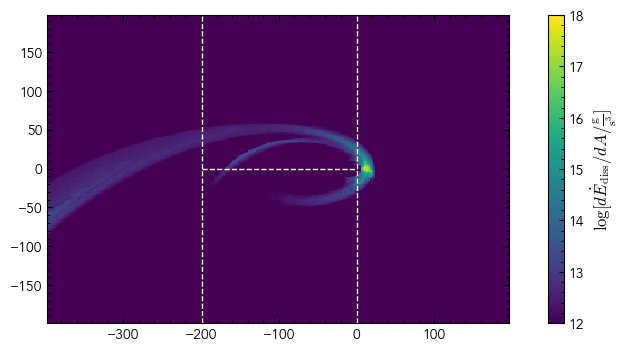

t_fb= 0.6738150129708113 dimensionless


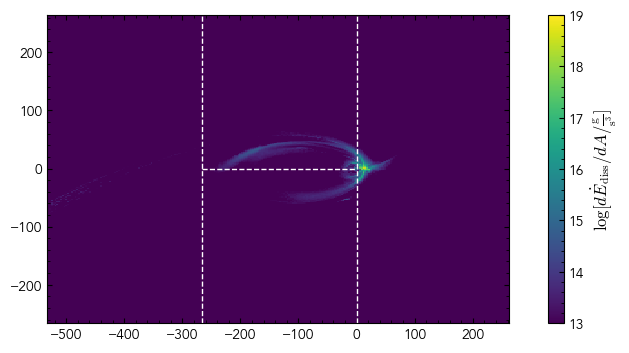

t_fb= 0.8977677118836747 dimensionless


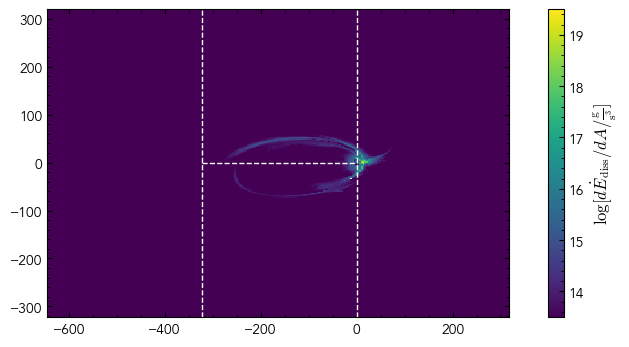

t_fb= 1.0559326395654778 dimensionless


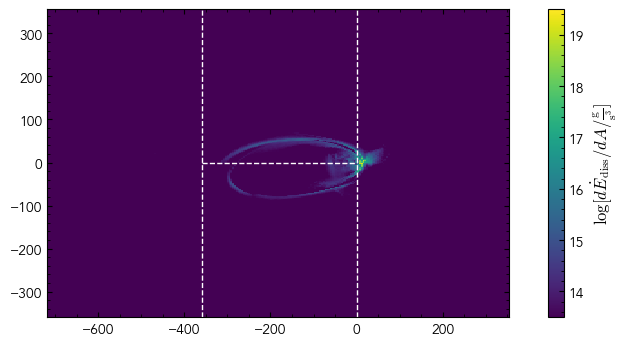

t_fb= 1.2141018677724082 dimensionless


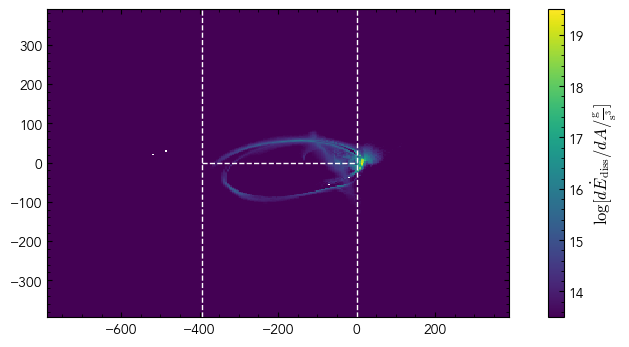

t_fb= 1.3722639123500922 dimensionless


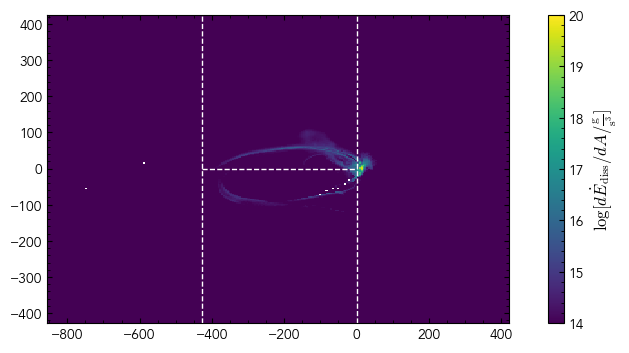

t_fb= 1.5304256304945272 dimensionless


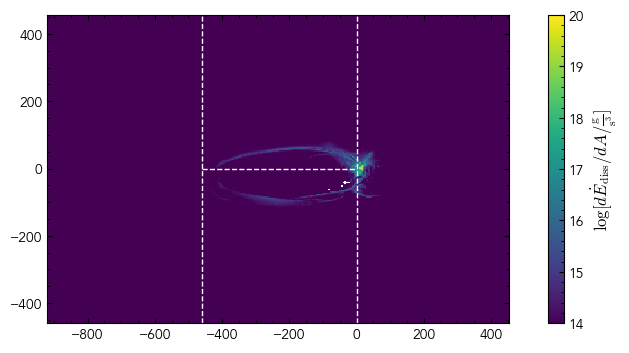

t_fb= 1.6885871058881319 dimensionless


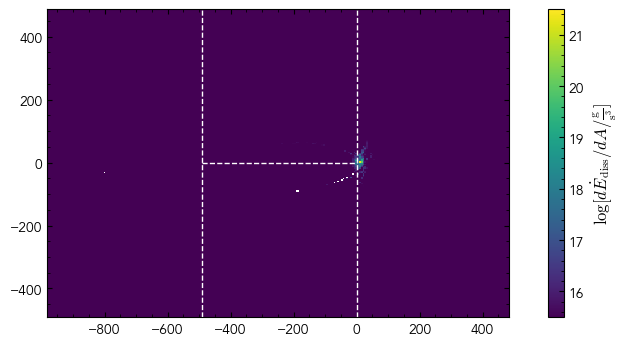

t_fb= 1.844648577682405 dimensionless


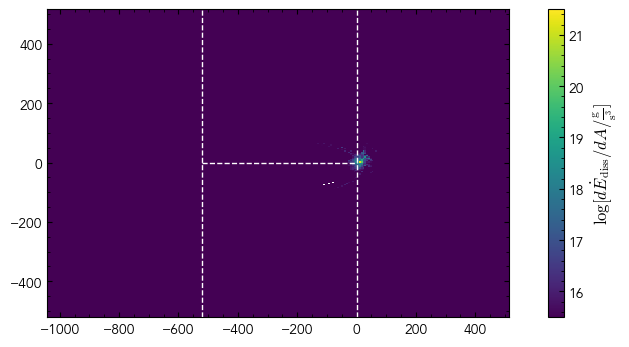

t_fb= 2.002807288479276 dimensionless


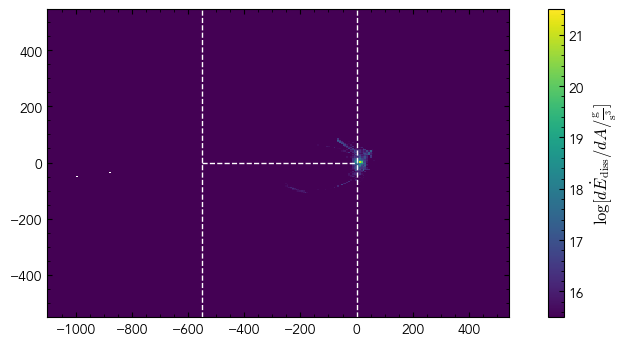

t_fb= 2.160985807933775 dimensionless


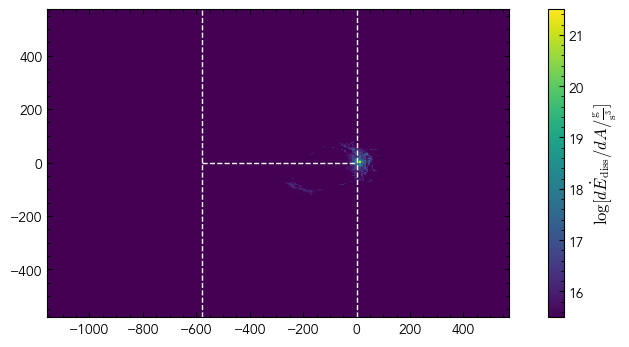

In [27]:
DATADIR = "/data1/projects/pi-rossiem/TDE_data/R0.47M0.5BH10000beta1S60n1.5ComptonHiResNewAMR/"
NCADENCE = 10

Rstar = 0.47 * richio.units.lscale
Mstar = 0.5 * richio.units.mscale
Mbh = 1e4 * richio.units.mscale
r_p = Rstar * (Mbh / Mstar) ** (1 / 3) * 1
r_amin = Rstar * (Mbh / Mstar) ** (2 / 3)
tmin = (
    np.pi / np.sqrt(2) * (Rstar**3 / u.G / Mstar) ** (1 / 2) * (Mbh / Mstar) ** (1 / 2)
)
Delta = u.G * Mbh / (4 * r_p) * Mstar

snap_files = sorted(
    glob.glob(os.path.join(DATADIR, "snap_*")),
    key=lambda f: int(re.search(r"snap_(\d+)", f).group(1)),
)

for snap_file in snap_files[21::NCADENCE]:
    snap = richio.load(snap_file)

    t = snap.tfb
    if t < 0:
        continue
    t_in_tmin = t / tmin
    r_a = r_amin * (t_in_tmin) ** (2 / 3)
    print("t_fb=", t_in_tmin)

    fig, ax = plt.subplots(figsize=(10, 4))
    snap.plots.projection(
        data="dissipation",
        res=256,
        X="CMx",
        Y="CMy",
        Z="CMz",
        box_size=[-2 * r_a, -r_a, -r_a, r_a, r_a, r_a],
        label_latex=r"d\dot{E}_\mathrm{diss}/dA",
        ax=ax,
        cmap="viridis",
    )

    ax.axvline(0, color="white", linestyle="--", linewidth=1)
    ax.axvline(-r_a, color="white", linestyle="--", linewidth=1)
    ax.plot([-r_a, 0], [0, 0], color="white", linestyle="--", linewidth=1)
    plt.show()
